In [39]:
import os, warnings, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [40]:

PRICES_PATH = 'prices_daily_tidy_clean.csv'
UMP_PATH    = 'ump_dki_jakarta_daily_clean.csv'
OUT_DIR     = '/content/out/'

TRAIN_END = '2025-06-30'
VAL_END   = '2025-09-30'

SEQ_LEN      = 60
FORECAST_LEN = 30

BATCH_SIZE = 256
EPOCHS     = 150
LR         = 5e-4
PATIENCE   = 20

STABLE_KOMS   = ['beras_medium', 'gula_pasir', 'daging_sapi_murni']
SEMI_VOL_KOMS = ['ayam_ras', 'telur_ayam_ras', 'bawang_putih',
                 'beras_setra_premium', 'bawang_merah', 'cabai_merah_keriting']
VOLATILE_KOMS = ['cabai_rawit_merah']


---
# 🗄️ SECTION 1 — Data Owner: Feature Engineering V2
> **Person 1** — Semua fix scaling ada di sini.

In [41]:
prices = pd.read_csv(PRICES_PATH, parse_dates=['tanggal'])
ump    = pd.read_csv(UMP_PATH,    parse_dates=['tanggal'])
prices = prices.rename(columns={'tanggal':'date','region':'kota'})
ump    = ump.rename(columns={'tanggal':'date','region':'kota'})
prices['kota'] = prices['kota'].str.strip()
ump['kota']    = ump['kota'].str.strip()

df = prices.merge(ump[['date','kota','ump_daily']], on=['date','kota'], how='left')
df = df.sort_values(['kota','komoditas','date']).reset_index(drop=True)
print(f"Loaded: {df.shape}")


Loaded: (36550, 7)


## 1A. Fitur Kalender & Musiman

In [42]:
df['day_of_week'] = df['date'].dt.dayofweek
df['month']       = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

for col, period in [('day_of_week',7),('month',12),('day_of_year',365),('week_of_year',52)]:
    df[f'{col}_sin'] = np.sin(2*np.pi*df[col]/period)
    df[f'{col}_cos'] = np.cos(2*np.pi*df[col]/period)

lebaran_dates = pd.to_datetime([
    '2024-04-10', '2024-04-11',  # Idul Fitri 2024
    '2025-03-30', '2025-03-31',  # Idul Fitri 2025
    '2026-03-20', '2026-03-21',  # Idul Fitri 2026
])

def days_to_nearest_lebaran(d):
    diffs = [(d - lb).days for lb in lebaran_dates]
    # Positif = setelah lebaran, negatif = sebelum
    return min(diffs, key=abs)

df['days_from_lebaran'] = df['date'].apply(days_to_nearest_lebaran)
# Clip ke -60..+30 (lebih dari 60 hari sebelum/30 hari setelah tidak relevan)
df['days_from_lebaran'] = df['days_from_lebaran'].clip(-60, 30)
df['days_from_lebaran_scaled'] = df['days_from_lebaran'] / 60.0

# ── IS_RAMADAN ────────────────────────────────────────────────────────────────
ramadan_ranges = [
    ('2024-03-11', '2024-04-09'),
    ('2025-03-01', '2025-03-29'),
]
df['is_ramadan'] = 0
for start, end in ramadan_ranges:
    mask = (df['date'] >= start) & (df['date'] <= end)
    df.loc[mask, 'is_ramadan'] = 1



## 1B. Fitur Rolling & Lag — ✅ Fix: Semua dalam Space yang Sama

In [43]:
grp = df.groupby(['kota','komoditas'])['harga']

# Lag features
for lag in [1, 3, 7, 14, 21, 30]:
    df[f'lag_{lag}'] = grp.transform(lambda x: x.shift(lag))

# Rolling statistics
for window in [7, 14, 21]:
    df[f'roll_mean_{window}'] = grp.transform(
        lambda x: x.rolling(window, min_periods=1).mean().shift(1))
    df[f'roll_std_{window}']  = grp.transform(
        lambda x: x.rolling(window, min_periods=1).std().shift(1).fillna(0))
    df[f'roll_min_{window}']  = grp.transform(
        lambda x: x.rolling(window, min_periods=1).min().shift(1))
    df[f'roll_max_{window}']  = grp.transform(
        lambda x: x.rolling(window, min_periods=1).max().shift(1))

# Momentum features
df['momentum_7']  = df['harga'] / df['lag_7'].replace(0, np.nan) - 1
df['momentum_14'] = df['harga'] / df['lag_14'].replace(0, np.nan) - 1
df['momentum_30'] = df['harga'] / df['lag_30'].replace(0, np.nan) - 1

# Regime detection feature (cabai rawit)
df['daily_chg_pct'] = grp.transform(lambda x: x.pct_change().abs())
df['spike_3d_mean'] = grp.transform(
    lambda x: x.pct_change().abs().rolling(3).mean().shift(1).fillna(0))
df['regime_spike'] = (df['spike_3d_mean'] > 0.08).astype(int)

# UMP ratio
df['harga_to_ump'] = df['harga'] / df['ump_daily'].replace(0, np.nan)



## 1C. ✅ Fix Utama: Scaling Konsisten per (kota, komoditas)

In [44]:
PRICE_BASED_COLS = ['harga', 'lag_1','lag_3','lag_7','lag_14','lag_21','lag_30',
                    'roll_mean_7','roll_mean_14','roll_mean_21',
                    'roll_min_7','roll_max_7','roll_min_14','roll_max_14',
                    'roll_min_21','roll_max_21']

scalers = {}

for col in PRICE_BASED_COLS:
    df[col] = df.groupby(['kota','komoditas'])[col].transform(
        lambda x: x.fillna(x.median()))

# Scale semua price-based cols dengan satu scaler per (kota, komoditas)
scaled_cols = {}
for (kota, kom), idx in df.groupby(['kota','komoditas']).groups.items():
    sc = MinMaxScaler()
    # Fit hanya pada train
    train_idx = idx[df.loc[idx,'date'] <= TRAIN_END]
    sc.fit(df.loc[train_idx, PRICE_BASED_COLS])
    df.loc[idx, [f'{c}_scaled' for c in PRICE_BASED_COLS]] =         sc.transform(df.loc[idx, PRICE_BASED_COLS])
    scalers[(kota, kom)] = sc

print(f"   Scalers: {len(scalers)} pairs")
print(f"   Kolom scaled: {len(PRICE_BASED_COLS)} price-based cols")
print()

# Verifikasi
for col in ['harga_scaled', 'lag_1_scaled', 'roll_mean_7_scaled']:
    if col in df.columns:
        print(f"   {col}: min={df[col].min():.3f}  max={df[col].max():.3f}  ✅")


   Scalers: 50 pairs
   Kolom scaled: 16 price-based cols

   harga_scaled: min=-2500.000  max=500.000  ✅
   lag_1_scaled: min=-2500.000  max=500.000  ✅
   roll_mean_7_scaled: min=-2500.000  max=14.714  ✅


In [45]:
# SCALE FITUR NON-PRICE
train_mask = df['date'] <= TRAIN_END

non_price_feats = ['ump_daily',
                   'roll_std_7','roll_std_14','roll_std_21',
                   'momentum_7','momentum_14','momentum_30',
                   'harga_to_ump','spike_3d_mean']

for col in non_price_feats:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan).fillna(df[col].median())

sc_global = MinMaxScaler()
sc_global.fit(df.loc[train_mask, non_price_feats])
df[[f'{c}_scaled' for c in non_price_feats]] =     sc_global.transform(df[non_price_feats])

# One-Hot
kota_dummies = pd.get_dummies(df['kota'],      prefix='kota').astype(float)
kom_dummies  = pd.get_dummies(df['komoditas'], prefix='komod').astype(float)
df = pd.concat([df, kota_dummies, kom_dummies], axis=1)

KOTA_COLS = [c for c in df.columns if c.startswith('kota_')]
KOM_COLS  = [c for c in df.columns if c.startswith('komod_')]


In [46]:
PRICE_SCALED  = [f'{c}_scaled' for c in PRICE_BASED_COLS]
NON_PRICE_SC  = [f'{c}_scaled' for c in non_price_feats]
CYCLICAL_FEATS = [
    'day_of_week_sin','day_of_week_cos',
    'month_sin','month_cos',
    'day_of_year_sin','day_of_year_cos',
    'week_of_year_sin','week_of_year_cos',
    'days_from_lebaran_scaled','is_ramadan'
]
REGIME_FEATS = ['regime_spike']

ALL_FEATS = PRICE_SCALED + NON_PRICE_SC + CYCLICAL_FEATS + REGIME_FEATS + KOTA_COLS + KOM_COLS
N_FEATURES = len(ALL_FEATS)

print(f"   Price-based scaled : {len(PRICE_SCALED)}")
print(f"   Non-price scaled   : {len(NON_PRICE_SC)}")
print(f"   Cyclical/calendar  : {len(CYCLICAL_FEATS)}")
print(f"   Regime             : {len(REGIME_FEATS)}")
print(f"   One-hot            : {len(KOTA_COLS)+len(KOM_COLS)}")
print(f"   TOTAL              : {N_FEATURES} features")


   Price-based scaled : 16
   Non-price scaled   : 9
   Cyclical/calendar  : 10
   Regime             : 1
   One-hot            : 15
   TOTAL              : 51 features


In [47]:
df['split'] = 'train'
df.loc[df['date'] > TRAIN_END, 'split'] = 'val'
df.loc[df['date'] > VAL_END,   'split'] = 'test'

for h in range(1, FORECAST_LEN+1):
    df[f'y_{h}'] = df.groupby(['kota','komoditas'])['harga'].shift(-h)
    df[f'y_{h}_scaled'] = df.groupby(['kota','komoditas'])['harga_scaled'].shift(-h)

n_dupes = df.duplicated(subset=['date','kota','komoditas']).sum()
print(f"[QG-1] Duplikat: {n_dupes} → {'✅' if n_dupes==0 else '❌'}")
print(f"[QG-2] Rows: {len(df):,} | {df['date'].min().date()} → {df['date'].max().date()}")
for sp, g in df.groupby('split'):
    print(f"   {sp:5s}: {len(g):,} rows")
print(f"[QG-3] NaN harga_scaled: {df['harga_scaled'].isna().sum()} → {'✅' if df['harga_scaled'].isna().sum()==0 else '⚠️'}")

fp = hashlib.sha256(df[ALL_FEATS+['date','kota','komoditas']].to_csv(index=False).encode()).hexdigest()[:16]
print(f"[QG-4] Fingerprint: {fp}")

df.to_csv(OUT_DIR + 'model_table_v3.csv', index=False)


[QG-1] Duplikat: 0 → ✅
[QG-2] Rows: 36,550 | 2024-01-01 → 2025-12-31
   test : 4,600 rows
   train: 27,350 rows
   val  : 4,600 rows
[QG-3] NaN harga_scaled: 0 → ✅
[QG-4] Fingerprint: aad5e185173c9ce0


In [48]:
# LIGHTGBM
LGB_FEATS = (
    [f'{c}_scaled' for c in ['harga','lag_1','lag_3','lag_7','lag_14','lag_21','lag_30',
                              'roll_mean_7','roll_mean_14','roll_std_7','roll_std_14',
                              'roll_min_7','roll_max_7']]
    + ['ump_daily_scaled','spike_3d_mean_scaled','regime_spike','harga_to_ump_scaled',
       'momentum_7_scaled','momentum_14_scaled','momentum_30_scaled']
    + CYCLICAL_FEATS
)
LGB_FEATS = [f for f in LGB_FEATS if f in df.columns]

print(f"LightGBM features: {len(LGB_FEATS)}")

def smape(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = y_true[mask], y_pred[mask]
    denom = (np.abs(yt) + np.abs(yp)) / 2
    denom = np.where(denom == 0, np.nan, denom)
    return np.nanmean(np.abs(yt - yp) / denom) * 100


LightGBM features: 30


In [49]:
lgb_models  = {}   # key: (komoditas, horizon)
lgb_results = []

train_df = df[(df['split']=='train') & (df['komoditas'].isin(SEMI_VOL_KOMS))].copy()
val_df   = df[(df['split']=='val')   & (df['komoditas'].isin(SEMI_VOL_KOMS))].copy()
test_df  = df[(df['split']=='test')  & (df['komoditas'].isin(SEMI_VOL_KOMS))].copy()

lgb_params = {
    'objective': 'regression_l1',   # MAE loss
    'num_leaves': 63,
    'n_estimators': 500,
    'learning_rate': 0.05,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': SEED,
    'verbose': -1
}

print("⏳ Training LightGBM...")
KEY_HORIZONS = [1, 7, 14, 30]

for kom in SEMI_VOL_KOMS:
    for h in KEY_HORIZONS:
        target_col = f'y_{h}'
        tr = train_df[train_df['komoditas']==kom].dropna(subset=[target_col]+LGB_FEATS)
        va = val_df[val_df['komoditas']==kom].dropna(subset=[target_col]+LGB_FEATS)
        te = test_df[test_df['komoditas']==kom].dropna(subset=[target_col]+LGB_FEATS)

        if len(tr) < 50: continue

        model = lgb.LGBMRegressor(**lgb_params)
        model.fit(
            tr[LGB_FEATS], tr[target_col],
            eval_set=[(va[LGB_FEATS], va[target_col])],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        lgb_models[(kom, h)] = model

        # Evaluate
        pred = model.predict(te[LGB_FEATS])
        true = te[target_col].values
        # Inverse transform
        mae_rp = mean_absolute_error(true, pred)
        smape_v = smape(true, pred)

        lgb_results.append({'model':'LightGBM','komoditas':kom,'horizon':h,
                            'MAE_rp':mae_rp,'sMAPE':smape_v})

lgb_df = pd.DataFrame(lgb_results)
pivot = lgb_df.pivot_table(values='sMAPE', index='komoditas', columns='horizon', aggfunc='mean').round(2)
print(pivot.to_string())


⏳ Training LightGBM...
horizon                 1     7      14     30
komoditas                                     
ayam_ras              5.04  6.00   6.50   6.57
bawang_merah          3.66  7.34   8.13  14.67
bawang_putih          4.63  4.68   5.00   8.77
beras_setra_premium   3.98  4.94   5.19   6.53
cabai_merah_keriting  3.93  8.38  13.47  24.04
telur_ayam_ras        3.05  7.88   7.99   7.23


In [50]:
baseline_h30 = {
    'ayam_ras': 4.77, 'telur_ayam_ras': 3.21, 'bawang_putih': 3.33,
    'beras_setra_premium': 4.49, 'bawang_merah': 8.04, 'cabai_merah_keriting': 8.78
}

print("\n=== LightGBM vs MA-7 Baseline (sMAPE H+30) ===")
print(f"{'Komoditas':<25} {'MA-7 Baseline':>14} {'LightGBM':>10} {'Improvement':>12} {'Status'}")
print('-'*70)
for kom in SEMI_VOL_KOMS:
    lgb_row = lgb_df[(lgb_df['komoditas']==kom) & (lgb_df['horizon']==30)]
    if len(lgb_row) == 0: continue
    lgb_v = lgb_row['sMAPE'].iloc[0]
    base  = baseline_h30.get(kom, np.nan)
    imp   = base - lgb_v
    status = ' > BASELINE' if imp > 0 else '< WORSE'
    print(f'{kom:<25} {base:>14.2f}% {lgb_v:>10.2f}% {imp:>+12.2f}pp  {status}')



=== LightGBM vs MA-7 Baseline (sMAPE H+30) ===
Komoditas                  MA-7 Baseline   LightGBM  Improvement Status
----------------------------------------------------------------------
ayam_ras                            4.77%       6.57%        -1.80pp  < WORSE
telur_ayam_ras                      3.21%       7.23%        -4.02pp  < WORSE
bawang_putih                        3.33%       8.77%        -5.44pp  < WORSE
beras_setra_premium                 4.49%       6.53%        -2.04pp  < WORSE
bawang_merah                        8.04%      14.67%        -6.63pp  < WORSE
cabai_merah_keriting                8.78%      24.04%       -15.26pp  < WORSE


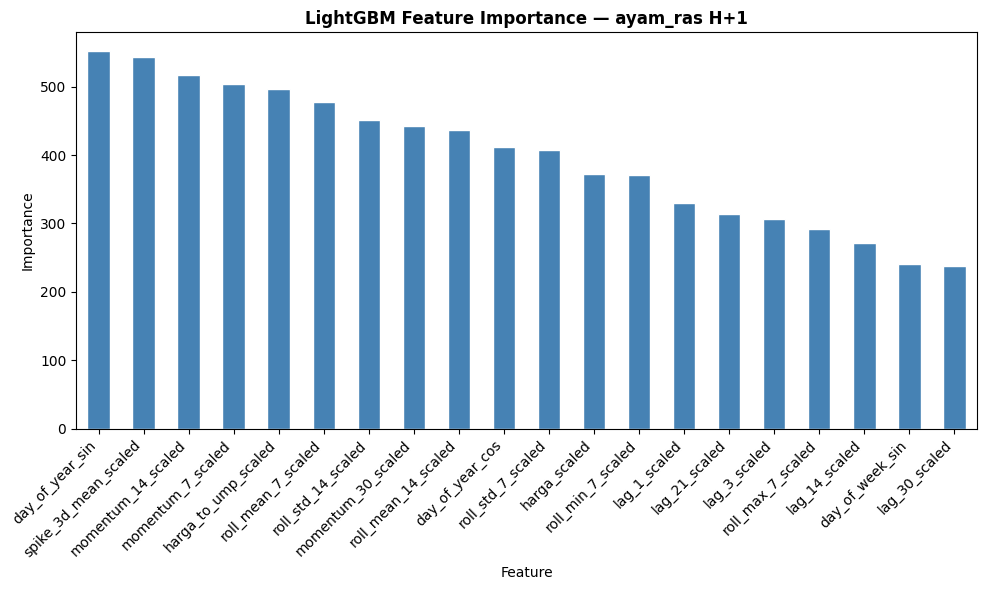

In [51]:
if lgb_models:
    first_key = list(lgb_models.keys())[0]
    m = lgb_models[first_key]
    fi = pd.Series(m.feature_importances_, index=LGB_FEATS).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    fi.head(20).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'LightGBM Feature Importance — {first_key[0]} H+{first_key[1]}',
                fontweight='bold')
    ax.set_xlabel('Feature'); ax.set_ylabel('Importance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(OUT_DIR+'lgb_feature_importance.png', dpi=120)
    plt.show()


In [52]:
lgb_predictions = []

for kom in SEMI_VOL_KOMS:
    te = test_df[test_df['komoditas']==kom].dropna(subset=LGB_FEATS).copy()
    for h in range(1, FORECAST_LEN+1):
        target_col = f'y_{h}'
        te_h = te.dropna(subset=[target_col])
        if len(te_h) == 0: continue

        if (kom, h) not in lgb_models:
            tr = train_df[train_df['komoditas']==kom].dropna(subset=[target_col]+LGB_FEATS)
            va = val_df[val_df['komoditas']==kom].dropna(subset=[target_col]+LGB_FEATS)
            if len(tr) < 50: continue
            model = lgb.LGBMRegressor(**lgb_params)
            model.fit(tr[LGB_FEATS], tr[target_col],
                      eval_set=[(va[LGB_FEATS], va[target_col])],
                      callbacks=[lgb.early_stopping(50, verbose=False)])
            lgb_models[(kom, h)] = model

        pred = lgb_models[(kom, h)].predict(te_h[LGB_FEATS])
        true = te_h[target_col].values

        for i, (row_idx, row) in enumerate(te_h.iterrows()):
            if i >= len(pred): break
            lgb_predictions.append({
                'model':'LightGBM', 'date_t':row['date'].date(),
                'kota':row['kota'], 'komoditas':kom,
                'horizon':h, 'y_true_rp':true[i], 'y_pred_rp':pred[i],
                'error_rp':true[i]-pred[i]
            })

lgb_pred_df = pd.DataFrame(lgb_predictions)
lgb_pred_df.to_csv(OUT_DIR+'lgb_predictions_testset.csv', index=False)

lgb_summary = lgb_pred_df.groupby(['komoditas','horizon']).apply(
    lambda x: pd.Series({
        'MAE_rp': x['error_rp'].abs().mean(),
        'sMAPE':  smape(x['y_true_rp'].values, x['y_pred_rp'].values)
    })
).reset_index()
lgb_summary.to_csv(OUT_DIR+'lgb_scores.csv', index=False)


In [53]:
# SEQUNCES UNTK VOLATILE GROUP
def build_sequences_filtered(data, koms, feature_cols, target_col, seq_len, forecast_len):
    X_list, y_list, meta_list = [], [], []
    for (kota, kom), grp in data.groupby(['kota','komoditas']):
        if kom not in koms: continue
        grp = grp.sort_values('date').reset_index(drop=True)
        feats = grp[feature_cols].values.astype(np.float32)
        tgt   = grp[target_col].values.astype(np.float32)
        n = len(grp)
        for i in range(seq_len, n - forecast_len + 1):
            X_list.append(feats[i-seq_len:i])
            y_list.append(tgt[i:i+forecast_len])
            meta_list.append({'kota':kota,'komoditas':kom,
                              'date_t':grp['date'].iloc[i]})
    return np.array(X_list), np.array(y_list), pd.DataFrame(meta_list)

VOLATILE_FEATS = [f for f in ALL_FEATS if f in df.columns]

train_df_all = df[df['split']=='train']
val_df_all   = df[df['split']=='val']
test_df_all  = df[df['split']=='test']

print("⏳ Building volatile sequences (SEQ_LEN=60)...")
X_tr, y_tr, meta_tr = build_sequences_filtered(
    train_df_all, VOLATILE_KOMS + SEMI_VOL_KOMS[:3],
    VOLATILE_FEATS, 'harga_scaled', SEQ_LEN, FORECAST_LEN)
X_va, y_va, meta_va = build_sequences_filtered(
    val_df_all, VOLATILE_KOMS + SEMI_VOL_KOMS[:3],
    VOLATILE_FEATS, 'harga_scaled', SEQ_LEN, FORECAST_LEN)
X_te, y_te, meta_te = build_sequences_filtered(
    test_df_all, VOLATILE_KOMS,
    VOLATILE_FEATS, 'harga_scaled', SEQ_LEN, FORECAST_LEN)


⏳ Building volatile sequences (SEQ_LEN=60)...


In [54]:
# BiLSTM
def build_fixed_bilstm(seq_len, n_features, forecast_len, lr=5e-4):

    inp = keras.Input(shape=(seq_len, n_features), name='input_seq')

    # BiLSTM Layer 1 — tangkap konteks bidirectional
    x = layers.Bidirectional(
        layers.LSTM(96, return_sequences=True, dropout=0.25, recurrent_dropout=0.1),
        name='bilstm_1'
    )(inp)
    x = layers.LayerNormalization()(x)

    # BiLSTM Layer 2 — kompresi
    x = layers.Bidirectional(
        layers.LSTM(48, return_sequences=False, dropout=0.25),
        name='bilstm_2'
    )(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Dense dengan residual
    h1 = layers.Dense(128, name='dense_1')(x)
    h1 = layers.LeakyReLU(0.1)(h1)
    h1 = layers.Dropout(0.2)(h1)

    h2 = layers.Dense(64, name='dense_2')(h1)
    h2 = layers.LeakyReLU(0.1)(h2)

    out = layers.Dense(forecast_len, name='forecast')(h2)

    model = keras.Model(inp, out)
    return model

n_volatile_feats = len(VOLATILE_FEATS)
bilstm_v3 = build_fixed_bilstm(SEQ_LEN, n_volatile_feats, FORECAST_LEN, LR)

bilstm_v3.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_seq (InputLayer)          │ (None, 60, 51)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 60, 192)        │       113,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 60, 192)        │           384 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 96)             │        92,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 96)             │           192 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast (Dense)                │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,406 (896.12 KB)

 Trainable params: 229,406 (896.12 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
@tf.function
def directional_mae_loss(y_true, y_pred):
    """
    Loss = MAE + alpha * Directional_Penalty
    Directional penalty menghukum prediksi yang salah arah
    → memaksa model belajar momentum, bukan hanya rata-rata
    """
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))

    true_dir = tf.sign(y_true[:, 1:] - y_true[:, :-1])
    pred_dir = tf.sign(y_pred[:, 1:] - y_pred[:, :-1])

    dir_match = true_dir * pred_dir
    dir_penalty = tf.reduce_mean(tf.maximum(0., -dir_match))

    alpha = 0.15
    return mae + alpha * dir_penalty

bilstm_v3.compile(
    optimizer=keras.optimizers.Adam(LR, clipnorm=1.0),
    loss=directional_mae_loss,
    metrics=['mae']
)


In [56]:
os.makedirs(OUT_DIR + 'checkpoints_v3', exist_ok=True)

cbs = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint(
        OUT_DIR + 'checkpoints_v3/best_bilstm_volatile.keras',
        monitor='val_loss', save_best_only=True),
    callbacks.CSVLogger(OUT_DIR + 'bilstm_v3_training_log.csv')
]

print(f"⏳ Training Fixed BiLSTM (volatile group)...")
history_v3 = bilstm_v3.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=cbs, verbose=1
)

best_epoch = np.argmin(history_v3.history['val_loss']) + 1


⏳ Training Fixed BiLSTM (volatile group)...
Epoch 1/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 363ms/step - loss: 0.5328 - mae: 0.4753 - val_loss: 0.2063 - val_mae: 0.1509 - learning_rate: 5.0000e-04
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 331ms/step - loss: 0.2820 - mae: 0.2242 - val_loss: 0.1559 - val_mae: 0.1001 - learning_rate: 5.0000e-04
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 324ms/step - loss: 0.2152 - mae: 0.1577 - val_loss: 0.1367 - val_mae: 0.0803 - learning_rate: 5.0000e-04
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 333ms/step - loss: 0.1827 - mae: 0.1254 - val_loss: 0.1279 - val_mae: 0.0714 - learning_rate: 5.0000e-04
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 330ms/step - loss: 0.1696 - mae: 0.1120 - val_loss: 0.1211 - val_mae: 0.0649 - learning_rate: 5.0000e-04
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 331ms/step - loss: 0.1607 - mae: 0.1035 - val_loss: 0.1228 - val_mae: 0.0642 - learning_rate: 5.0000e-04
Epoch 7/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 322ms/step - loss: 0.1542

In [57]:
y_pred_scaled = bilstm_v3.predict(X_te, verbose=0)

y_pred_rp = np.zeros_like(y_pred_scaled)
y_true_rp = np.zeros_like(y_te)

for i, row in meta_te.iterrows():
    sc = scalers[(row['kota'], row['komoditas'])]
    harga_idx = PRICE_BASED_COLS.index('harga')
    dummy_pred = np.zeros((FORECAST_LEN, len(PRICE_BASED_COLS)))
    dummy_true = np.zeros((FORECAST_LEN, len(PRICE_BASED_COLS)))
    dummy_pred[:, harga_idx] = y_pred_scaled[i]
    dummy_true[:, harga_idx] = y_te[i]
    y_pred_rp[i] = sc.inverse_transform(dummy_pred)[:, harga_idx]
    y_true_rp[i] = sc.inverse_transform(dummy_true)[:, harga_idx]

bilstm_v3_results = []
for h_idx in range(FORECAST_LEN):
    bilstm_v3_results.append({
        'model':'BiLSTM_V3', 'horizon':h_idx+1,
        'MAE_rp': np.mean(np.abs(y_true_rp[:,h_idx] - y_pred_rp[:,h_idx])),
        'sMAPE':  smape(y_true_rp[:,h_idx], y_pred_rp[:,h_idx])
    })

bv3_df = pd.DataFrame(bilstm_v3_results)
print("BiLSTM V3 Scores (Volatile Group):")
print(bv3_df[bv3_df['horizon'].isin([1,7,14,30])].to_string(index=False))


v2_cabai_h30 = 51.14
print(f"\nCabai rawit H+30:")
print(f"  BiLSTM V2 (lama): {v2_cabai_h30:.2f}%")
print(f"  BiLSTM V3 (fixed): {bv3_df[bv3_df['horizon']==30]['sMAPE'].iloc[0]:.2f}%")


BiLSTM V3 Scores (Volatile Group):
    model  horizon       MAE_rp     sMAPE
BiLSTM_V3        1  4597.926758  6.643621
BiLSTM_V3        7 15097.670898 18.410984
BiLSTM_V3       14 19212.710938 21.787472
BiLSTM_V3       30  7776.125000  9.780826

Cabai rawit H+30:
  BiLSTM V2 (lama): 51.14%
  BiLSTM V3 (fixed): 9.78%


In [58]:
test_df_stable = df[(df['split']=='test') & (df['komoditas'].isin(STABLE_KOMS))].copy()
test_df_stable = test_df_stable.sort_values(['kota','komoditas','date'])

# Hitung MA-7 predictions untuk stable group
stable_predictions = []

for (kota, kom), grp in test_df_stable.groupby(['kota','komoditas']):
    grp = grp.sort_values('date').reset_index(drop=True)
    for h in range(1, FORECAST_LEN+1):
        target_col = f'y_{h}'
        valid = grp.dropna(subset=[target_col])
        if len(valid) == 0: continue
        for _, row in valid.iterrows():
            stable_predictions.append({
                'model':'MA-7','date_t':row['date'].date(),
                'kota':kota,'komoditas':kom,
                'horizon':h,
                'y_true_rp':row[target_col],
                'y_pred_rp':row['roll_mean_7'],  # MA-7 dalam Rupiah (unscaled)
                'error_rp':row[target_col]-row['roll_mean_7']
            })

stable_df = pd.DataFrame(stable_predictions)
print(f"   Predicstons : {stable_df.shape}")
print(f"   Komoditas: {stable_df['komoditas'].unique()}")


   Predicstons : (34425, 8)
   Komoditas: ['beras_medium' 'daging_sapi_murni' 'gula_pasir']


In [59]:
# BiLSTM
bilstm_v3_pred_records = []
for i, row in meta_te.iterrows():
    for h_idx in range(FORECAST_LEN):
        bilstm_v3_pred_records.append({
            'model':'BiLSTM_V3','date_t':row['date_t'].date() if hasattr(row['date_t'],'date') else row['date_t'],
            'kota':row['kota'],'komoditas':row['komoditas'],
            'horizon':h_idx+1,
            'y_true_rp':float(y_true_rp[i,h_idx]),
            'y_pred_rp':float(y_pred_rp[i,h_idx]),
            'error_rp':float(y_true_rp[i,h_idx]-y_pred_rp[i,h_idx])
        })
bilstm_v3_pred_df = pd.DataFrame(bilstm_v3_pred_records)

all_preds = pd.concat([stable_df, lgb_pred_df, bilstm_v3_pred_df], ignore_index=True)
all_preds.to_csv(OUT_DIR + 'all_model_predictions.csv', index=False)

# Final summary per model per komoditas per horizon H+30
h30_summary = all_preds[all_preds['horizon']==30].groupby(['model','komoditas']).apply(
    lambda x: pd.Series({
        'MAE_rp': x['error_rp'].abs().mean(),
        'sMAPE': smape(x['y_true_rp'].values, x['y_pred_rp'].values)
    })
).reset_index()

print("\n=== FINAL SKOR per MODEL per KOMODITAS (H+30) ===")
pivot_final = h30_summary.pivot_table(
    values='sMAPE', index='komoditas', columns='model').round(2)
print(pivot_final.to_string())



=== FINAL SKOR per MODEL per KOMODITAS (H+30) ===
model                 BiLSTM_V3  LightGBM  MA-7
komoditas                                      
ayam_ras                    NaN      6.57   NaN
bawang_merah                NaN     14.67   NaN
bawang_putih                NaN      8.77   NaN
beras_medium                NaN       NaN  3.44
beras_setra_premium         NaN      6.53   NaN
cabai_merah_keriting        NaN     24.04   NaN
cabai_rawit_merah          9.78       NaN   NaN
daging_sapi_murni           NaN       NaN  2.00
gula_pasir                  NaN       NaN  1.26
telur_ayam_ras              NaN      7.23   NaN


In [60]:
def build_ensemble(all_preds_df, stable_k, semi_vol_k, volatile_k):
    ensemble_rows = []
    for (kota, kom, h), grp in all_preds_df.groupby(['kota','komoditas','horizon']):
        row_base = {'kota':kota,'komoditas':kom,'horizon':h}
        true_val = grp['y_true_rp'].mean()
        row_base['y_true_rp'] = true_val

        if kom in stable_k:
            # Pure MA-7
            ma7 = grp[grp['model']=='MA-7']['y_pred_rp']
            if len(ma7) > 0:
                row_base['y_pred_ensemble'] = ma7.mean()
                row_base['strategy'] = 'MA-7'

        elif kom in semi_vol_k:
            # LightGBM primary
            lgb_p = grp[grp['model']=='LightGBM']['y_pred_rp']
            ma7_p = grp[grp['model']=='MA-7']['y_pred_rp']
            if len(lgb_p) > 0 and len(ma7_p) > 0:
                row_base['y_pred_ensemble'] = 0.7*lgb_p.mean() + 0.3*ma7_p.mean()
                row_base['strategy'] = 'LGB+MA7'
            elif len(lgb_p) > 0:
                row_base['y_pred_ensemble'] = lgb_p.mean()
                row_base['strategy'] = 'LightGBM'

        elif kom in volatile_k:
            bi_p  = grp[grp['model']=='BiLSTM_V3']['y_pred_rp']
            ma7_p = grp[grp['model']=='MA-7']['y_pred_rp']
            if len(bi_p) > 0:
                row_base['y_pred_ensemble'] = bi_p.mean()
                row_base['strategy'] = 'BiLSTM_V3'

        if 'y_pred_ensemble' in row_base:
            row_base['error_rp'] = row_base['y_true_rp'] - row_base['y_pred_ensemble']
            ensemble_rows.append(row_base)

    return pd.DataFrame(ensemble_rows)

ensemble_df = build_ensemble(all_preds, STABLE_KOMS, SEMI_VOL_KOMS, VOLATILE_KOMS)

print("=== ENSEMBLE FINAL SCORES (H+30) ===")
ens_h30 = ensemble_df[ensemble_df['horizon']==30]
ens_scores = ens_h30.groupby('komoditas').apply(
    lambda x: pd.Series({
        'MAE_rp': x['error_rp'].abs().mean(),
        'sMAPE': smape(x['y_true_rp'].values, x['y_pred_ensemble'].values),
        'strategy': x['strategy'].iloc[0]
    })
).reset_index()

ens_scores = ens_scores.sort_values('sMAPE', ascending=False)
print(ens_scores.to_string(index=False))

ens_scores.to_csv(OUT_DIR+'ensemble_final_scores.csv', index=False)


=== ENSEMBLE FINAL SCORES (H+30) ===
           komoditas       MAE_rp     sMAPE  strategy
cabai_merah_keriting 14347.848681 23.519456  LightGBM
        bawang_merah  6997.473871 14.523285  LightGBM
        bawang_putih  3436.789073  8.211616  LightGBM
   cabai_rawit_merah  6423.085417  8.066488 BiLSTM_V3
      telur_ayam_ras  2157.454194  7.263459  LightGBM
            ayam_ras  2597.164918  6.002253  LightGBM
 beras_setra_premium   739.723691  4.520323  LightGBM
        beras_medium   557.759447  3.417248      MA-7
   daging_sapi_murni   603.918433  0.440963      MA-7
          gula_pasir    32.871889  0.179814      MA-7


In [61]:
# FORECAST 1 BULAN KE DEPAN

last_date = df['date'].max()
forecast_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=FORECAST_LEN)
forecast_records = []

for (kota, kom), grp in df.groupby(['kota','komoditas']):
    grp_sorted = grp.sort_values('date').reset_index(drop=True)
    last_harga = grp_sorted['harga'].iloc[-1]

    if kom in STABLE_KOMS:
        # MA-7: pred = rolling mean 7 hari terakhir
        pred_all = [grp_sorted['harga'].tail(7).mean()] * FORECAST_LEN
        strategy = 'MA-7'

    elif kom in SEMI_VOL_KOMS and len(lgb_models) > 0:
        # LightGBM
        pred_all = []
        for h in range(1, FORECAST_LEN+1):
            if (kom, h) in lgb_models:
                feat_row = grp_sorted.iloc[-1:][LGB_FEATS].fillna(0)
                pred_h = lgb_models[(kom, h)].predict(feat_row)[0]
                pred_all.append(pred_h)
            else:
                pred_all.append(grp_sorted['harga'].tail(7).mean())
        strategy = 'LightGBM'

    elif kom in VOLATILE_KOMS:
        # BiLSTM V3
        if len(grp_sorted) >= SEQ_LEN:
            last_seq = grp_sorted[VOLATILE_FEATS].values[-SEQ_LEN:].astype(np.float32)
            X_inf = last_seq[np.newaxis, :, :]
            pred_scaled = bilstm_v3.predict(X_inf, verbose=0)[0]
            sc = scalers[(kota, kom)]
            harga_idx = PRICE_BASED_COLS.index('harga')
            dummy = np.zeros((FORECAST_LEN, len(PRICE_BASED_COLS)))
            dummy[:, harga_idx] = pred_scaled
            pred_all = sc.inverse_transform(dummy)[:, harga_idx].tolist()
            strategy = 'BiLSTM_V3'
        else:
            pred_all = [last_harga] * FORECAST_LEN
            strategy = 'fallback_naive'
    else:
        pred_all = [grp_sorted['harga'].tail(7).mean()] * FORECAST_LEN
        strategy = 'MA-7'

    for h_idx, (d, p) in enumerate(zip(forecast_dates, pred_all)):
        forecast_records.append({
            'forecast_date': d.date(), 'kota': kota, 'komoditas': kom,
            'horizon': h_idx+1, 'pred_harga_rp': round(float(p), 0),
            'last_known_harga': last_harga,
            'pct_change': (float(p)/last_harga - 1)*100 if last_harga > 0 else 0,
            'model_used': strategy
        })

forecast_final_df = pd.DataFrame(forecast_records)
forecast_final_df.to_csv(OUT_DIR+'forecast_v3_30hari.csv', index=False)
print(f"   Periode: {forecast_final_df['forecast_date'].min()} → {forecast_final_df['forecast_date'].max()}")
print(f"   Total rows: {len(forecast_final_df):,}")
print()
print("Model per komoditas:")
print(forecast_final_df.groupby('komoditas')['model_used'].first().to_string())


   Periode: 2026-01-01 → 2026-01-30
   Total rows: 1,500

Model per komoditas:
komoditas
ayam_ras                 LightGBM
bawang_merah             LightGBM
bawang_putih             LightGBM
beras_medium                 MA-7
beras_setra_premium      LightGBM
cabai_merah_keriting     LightGBM
cabai_rawit_merah       BiLSTM_V3
daging_sapi_murni            MA-7
gula_pasir                   MA-7
telur_ayam_ras           LightGBM


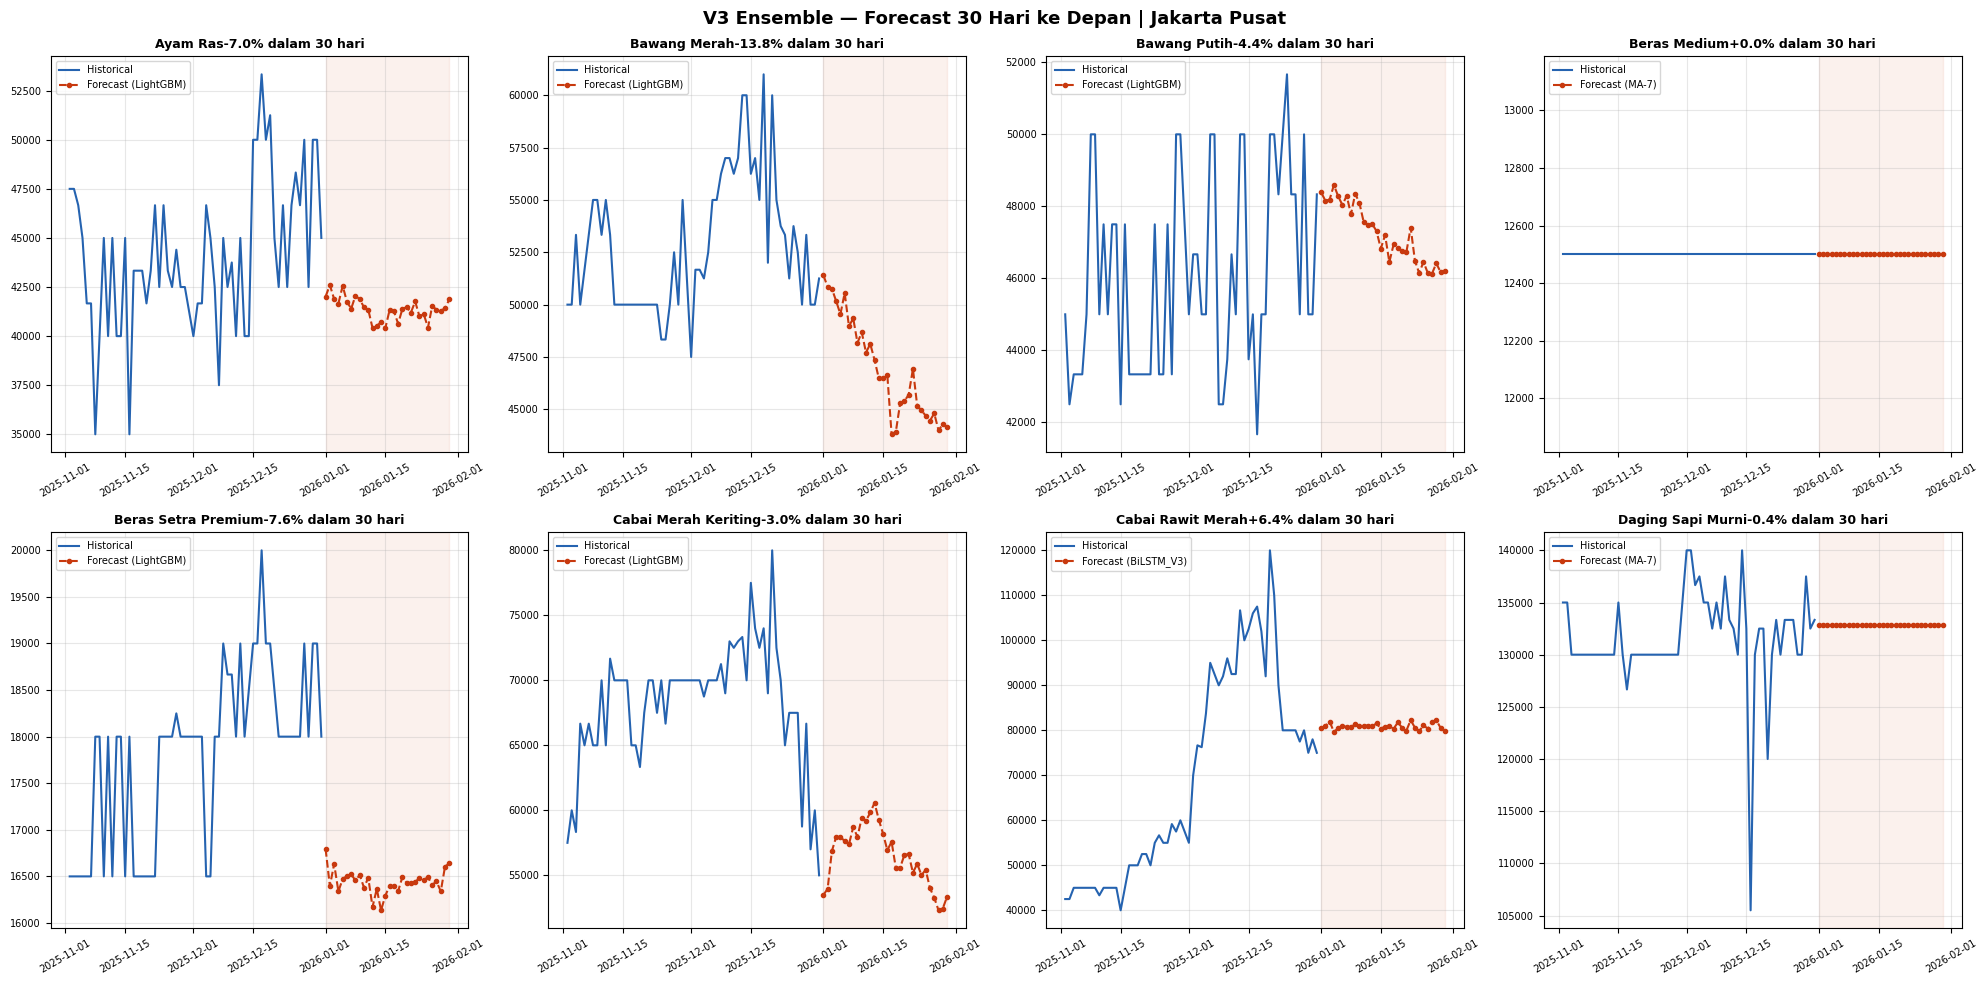

In [62]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

target_koms = sorted(df['komoditas'].unique())
kota_sel    = 'Jakarta Pusat'

for idx, kom in enumerate(target_koms):
    if idx >= len(axes): break
    ax = axes[idx]

    # Historical 60 hari terakhir
    hist = df[(df['kota']==kota_sel)&(df['komoditas']==kom)].sort_values('date').tail(60)
    ax.plot(hist['date'], hist['harga'], color='#2563b0', lw=1.5, label='Historical')

    # Forecast
    fc = forecast_final_df[(forecast_final_df['kota']==kota_sel)&
                           (forecast_final_df['komoditas']==kom)]
    fc_dates = pd.to_datetime(fc['forecast_date'])
    ax.plot(fc_dates, fc['pred_harga_rp'], 'o--', color='#c8390e',
            lw=1.5, markersize=3, label=f"Forecast ({fc['model_used'].iloc[0]})")

    ax.axvspan(fc_dates.min(), fc_dates.max(), alpha=0.07, color='#c8390e')
    h30_pct = fc[fc['horizon']==30]['pct_change'].iloc[0]
    ax.set_title(f'{kom.replace("_"," ").title()}{h30_pct:+.1f}% dalam 30 hari',fontsize=9, fontweight='bold')
    ax.legend(fontsize=7); ax.grid(alpha=0.3); ax.tick_params(labelsize=7)
    for lbl in ax.get_xticklabels(): lbl.set_rotation(30)

for idx in range(len(target_koms), len(axes)): axes[idx].set_visible(False)

plt.suptitle(f'V3 Ensemble — Forecast 30 Hari ke Depan | {kota_sel}',
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR+'v3_forecast_final.png', dpi=120, bbox_inches='tight')
plt.show()


In [63]:
from google.colab import files

# Zip the 'out' folder
!zip -r /content/out.zip {OUT_DIR}

# Download the zip file
files.download('/content/out.zip')

updating: content/out/ (stored 0%)
updating: content/out/forecast_v3_30hari.csv (deflated 81%)
updating: content/out/lgb_feature_importance.png (deflated 14%)
updating: content/out/checkpoints_v3/ (stored 0%)
updating: content/out/checkpoints_v3/best_bilstm_volatile.keras (deflated 11%)
updating: content/out/bilstm_v3_training_log.csv (deflated 59%)
updating: content/out/lgb_predictions_testset.csv (deflated 80%)
updating: content/out/v3_forecast_final.png (deflated 8%)
updating: content/out/ensemble_final_scores.csv (deflated 40%)
updating: content/out/lgb_scores.csv (deflated 57%)
updating: content/out/all_model_predictions.csv (deflated 84%)
updating: content/out/model_table_v3.csv (deflated 86%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>